# 🔮 Step 4: Prediction & Analysis

Use the trained model to classify new images and calculate areas.

## What This Notebook Does:
- ✅ Load trained CNN model
- ✅ Load new/test satellite images
- ✅ Make predictions
- ✅ Visualize results
- ✅ Calculate area changes (km²)

---

**Previous:** [03_model_training.ipynb](03_model_training.ipynb)  
**Next:** [05_visualization_reports.ipynb](05_visualization_reports.ipynb)

## Load Model and Data

In [19]:
# Cell: Load Model and Data

import rasterio
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

# Load trained model
print("📂 Loading trained model...")
model = joblib.load("outputs/coastal_classifier_model.pkl")
scaler = joblib.load("outputs/feature_scaler.pkl")

# Load metadata
print("📂 Loading metadata...")
with open("outputs/model_metadata.json") as f:
    metadata = json.load(f)

# Use 'classes' instead of 'class_names'
class_names = {i: str(name) for i, name in enumerate(metadata['classes'])}

print(f"✅ Model loaded!")
print(f"   Test Accuracy: {metadata['test_accuracy']*100:.2f}%")
print(f"   Classes: {list(class_names.values())}")

📂 Loading trained model...
📂 Loading metadata...
✅ Model loaded!
   Test Accuracy: 86.24%
   Classes: ['1', '2', '3', '4', '5']


## Load New Images for Prediction

*For this demo, using the same images. In production, load different year's data.*

In [20]:
# Load bands (for demo, using same images - replace with new year's data)
print("📂 Loading images...")
new_B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)
new_B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)
new_B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)
new_B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)

# Calculate NDVI
new_ndvi = (new_B08 - new_B04) / (new_B08 + new_B04 + 1e-10)

# Store shape for reshaping
original_shape = new_B02.shape

# Flatten and prepare
new_data = np.stack([
    new_B02.flatten(),
    new_B03.flatten(),
    new_B04.flatten(),
    new_B08.flatten(),
    new_ndvi.flatten()
], axis=1)

new_X = new_data.reshape(-1, 5, 1)

print(f"✅ Images loaded!")
print(f"   Shape: {original_shape}")
print(f"   Pixels: {new_X.shape[0]:,}")

📂 Loading images...
✅ Images loaded!
   Shape: (424, 480)
   Pixels: 203,520


## Make Predictions and Reshape

In [21]:
# Cell: Make Predictions and Reshape

# Load the processed image with all 7 bands
print("📂 Loading processed image...")
with rasterio.open("processed_image_with_indices.tif") as src:
    image_data = src.read()
    profile = src.profile.copy()

print(f"Making predictions on processed image...")
print(f"Image shape: {image_data.shape}")

# Identify nodata pixels BEFORE prediction
bands, height, width = image_data.shape
nodata_mask = np.all(image_data == 0, axis=0) | np.any(np.isnan(image_data), axis=0)

print(f"Nodata pixels detected: {np.sum(nodata_mask):,}")

# Reshape: (7, H, W) -> (H*W, 7)
reshaped_img = image_data.reshape(bands, -1).T 

# Handle NaNs
reshaped_img = np.nan_to_num(reshaped_img, nan=0)

# Scale using the saved scaler
reshaped_img_scaled = scaler.transform(reshaped_img)

# Predict!
print("🔮 Making predictions... (this may take a minute)")
prediction_flat = model.predict(reshaped_img_scaled)

# Add this after prediction_flat = model.predict(reshaped_img_scaled)

prediction_flat_filtered = prediction_flat.copy()
prediction_flat = prediction_flat_filtered
# Set nodata pixels to 0 AFTER prediction
prediction_flat[nodata_mask.flatten()] = 0

# Reshape back to map: (H*W) -> (H, W)
prediction_map = prediction_flat.reshape(height, width)


print(f"✅ Predictions complete!")
print(f"   Predicted classes (excluding nodata): {np.unique(prediction_flat[prediction_flat > 0])}")

📂 Loading processed image...
Making predictions on processed image...
Image shape: (7, 424, 480)
Nodata pixels detected: 0
🔮 Making predictions... (this may take a minute)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


✅ Predictions complete!
   Predicted classes (excluding nodata): [1 2 3 4 5]


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.3s finished


In [22]:
# Quick diagnostic - run this between prediction and save cells
print("prediction_flat" in dir())
print("prediction_map" in dir())
try:
    print(f"prediction_flat shape: {prediction_flat.shape}")
    print(f"prediction_map shape: {prediction_map.shape}")
except NameError as e:
    print(f"Missing variable: {e}")

True
True
prediction_flat shape: (203520,)
prediction_map shape: (424, 480)


## Save and Visualize

✅ Map saved as 'final_classification_map.tif'


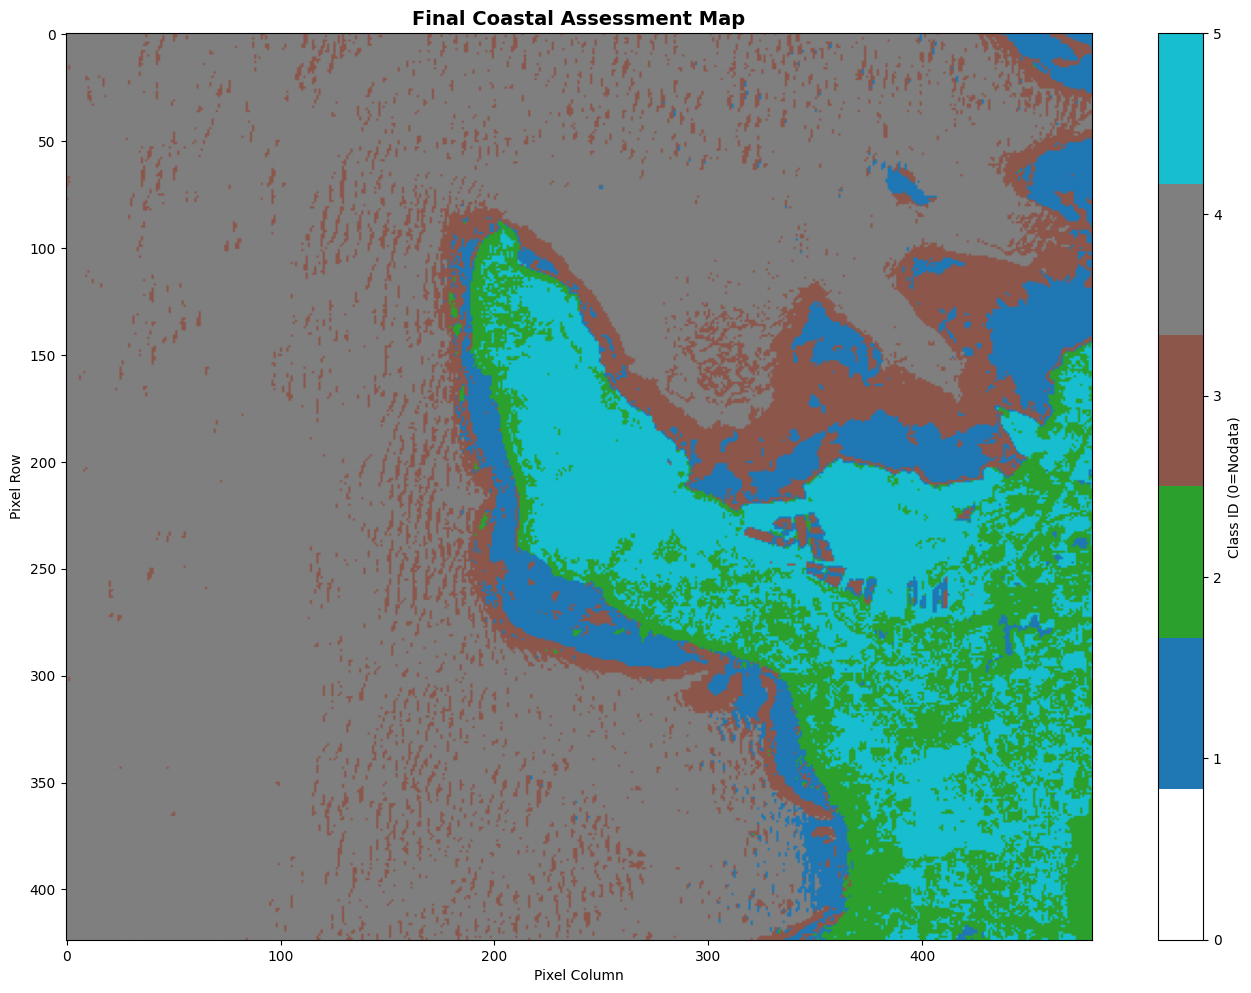


📋 Labels Mapping:
   Class 1: 1 - 13,943 pixels (6.85%)
   Class 2: 2 - 18,323 pixels (9.00%)
   Class 3: 3 - 22,886 pixels (11.25%)
   Class 4: 4 - 122,933 pixels (60.40%)
   Class 5: 5 - 25,435 pixels (12.50%)

📊 Class Distribution Summary:
   4: 60.4%
   5: 12.5%
   3: 11.2%
   2: 9.0%
   1: 6.9%


In [23]:
# Cell: Save and Visualize

import rasterio
from rasterio.transform import Affine

# Load the original processed image to get geospatial metadata
with rasterio.open("processed_image_with_indices.tif") as src:
    profile = src.profile.copy()

# Update profile for single-band output
profile.update(count=1, dtype=rasterio.uint8, nodata=0)

# Map prediction classes to numeric IDs for GeoTIFF (skip 0 = nodata)
valid_predictions = prediction_flat[prediction_flat > 0]
unique_labels = np.unique(valid_predictions)
label_to_id = {label: i for i, label in enumerate(unique_labels, 1)}

# Use simple mapping instead of np.vectorize
prediction_numeric = np.zeros_like(prediction_map, dtype=rasterio.uint8)
for label, id_num in label_to_id.items():
    prediction_numeric[prediction_map == label] = id_num

# Save as GeoTIFF
with rasterio.open("final_classification_map.tif", 'w', **profile) as dst:
    dst.write(prediction_numeric, 1)

print("✅ Map saved as 'final_classification_map.tif'")

# Create custom colormap
from matplotlib.colors import ListedColormap
colors = ['white'] + list(plt.cm.tab10(np.linspace(0, 1, len(unique_labels))))
cmap = ListedColormap(colors)

# Visualize
plt.figure(figsize=(14, 10))
im = plt.imshow(prediction_numeric, cmap=cmap, vmin=0, vmax=len(unique_labels))
cbar = plt.colorbar(im, label='Class ID', ticks=range(0, len(unique_labels)+1))
cbar.set_label('Class ID (0=Nodata)')
plt.title("Final Coastal Assessment Map", fontsize=14, fontweight='bold')
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.tight_layout()
plt.show()

print("\n📋 Labels Mapping:")
class_distribution = {}
for label, id_num in label_to_id.items():
    count = np.sum(prediction_flat == label)
    percentage = (count / len(valid_predictions)) * 100
    class_distribution[label] = {'id': id_num, 'count': count, 'percentage': percentage}
    print(f"   Class {id_num}: {label} - {count:,} pixels ({percentage:.2f}%)")

print("\n📊 Class Distribution Summary:")
for label, info in sorted(class_distribution.items(), key=lambda x: x[1]['count'], reverse=True):
    print(f"   {label}: {info['percentage']:.1f}%")



## Calculate Area by Class

In [24]:
# Cell: Calculate Area by Class

import pandas as pd

# 1. Define Pixel Size for Sentinel-2
pixel_size_meters = 10
area_per_pixel_sqm = pixel_size_meters * pixel_size_meters  # 100 m²

# 2. Count the pixels for each class
# 'prediction_flat' comes from the model.predict() step in the previous cell
unique_labels, counts = np.unique(prediction_flat, return_counts=True)

# 3. Create a Summary Table
results = []

for label, count in zip(unique_labels, counts):
    area_sqm = count * area_per_pixel_sqm
    area_hectares = area_sqm / 10000       # 10,000 m² = 1 Hectare
    area_sqkm = area_sqm / 1e6             # 1,000,000 m² = 1 km²
    
    results.append({
        "Class Name": label,
        "Pixel Count": count,
        "Area (m²)": f"{area_sqm:,.0f}",
        "Area (Hectares)": f"{area_hectares:,.2f}",
        "Area (km²)": f"{area_sqkm:,.4f}"
    })

# 4. Display as a clean DataFrame
area_df = pd.DataFrame(results)
print("--- 📊 Coastal Assessment Area Report ---")
print(area_df.to_string(index=False))

# Optional: Save report to CSV
area_df.to_csv("final_area_report.csv", index=False)

print("\n💾 Results saved to 'final_area_report.csv'")
print("\n" + "="*60)
print("✅ PREDICTION & ANALYSIS COMPLETE!")
print("="*60)
print("\n📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends")

--- 📊 Coastal Assessment Area Report ---
 Class Name  Pixel Count  Area (m²) Area (Hectares) Area (km²)
          1        13943  1,394,300          139.43     1.3943
          2        18323  1,832,300          183.23     1.8323
          3        22886  2,288,600          228.86     2.2886
          4       122933 12,293,300        1,229.33    12.2933
          5        25435  2,543,500          254.35     2.5435

💾 Results saved to 'final_area_report.csv'

✅ PREDICTION & ANALYSIS COMPLETE!

📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends
